In [16]:
#getting python plotting functions, problems when I copy python folder into env modules folder
import sys
sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp

import sys
from pathlib import Path
import os

riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

In [17]:
import os
import requests
zenodo_files=['rawdata_brain_radial_96proj_12ch.h5', 'rawdata_spiral_ETH.h5']
data_dir = 'rrsg'
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)

for zf in zenodo_files:
    if not os.path.isfile(f'{data_dir}/{zf}'):
        print(f'Downloading {zf}')
        res = requests.get(f'https://zenodo.org/record/3975887/files/{zf}')
        with open(f'{data_dir}/{zf}', 'wb') as h5f:
            h5f.write(res.content)
    else:
        print(f'Already downloaded {zf}')

Already downloaded rawdata_brain_radial_96proj_12ch.h5
Already downloaded rawdata_spiral_ETH.h5


In [18]:
import h5py
import numpy as np
matrix_sizes = [[256, 256], [220, 220]]
voxel_sizes = [[0.78, 0.78, 2], [1, 1, 2]]
scales = [1e8, 1]
radial_stem = 'rrsg-radial'
spiral_stem = 'rrsg-spiral'
rpre=f'{data_dir}/{radial_stem}'
spre=f'{data_dir}/{spiral_stem}'
riesling_files = [f'{radial_stem}.h5', f'{spiral_stem}.h5']
for (inname, mtx, vox, scale, outname) in zip(zenodo_files, matrix_sizes, voxel_sizes, scales, riesling_files):
    with h5py.File(f'{data_dir}/{inname}', 'r') as data_f:
        rawdata = data_f['rawdata'][...][np.newaxis,...].transpose((0,1,3,2,4))
        traj = data_f['trajectory'][...]
    traj = traj.transpose((2, 1, 0))
    if traj.shape[2] == 3: # Strip 3rd dimension of radial dataset
        traj = traj[:,:,0:2]
    info = rlp.io.__info()
    print(info)
    info['voxel_size'] = vox
    rlp.io.write(f'{data_dir}/{outname}', rawdata, traj, mtx, info=info)

{'voxel_size': [1, 1, 1], 'origin': [0, 0, 0], 'direction': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 'tr': 1}
{'voxel_size': [1, 1, 1], 'origin': [0, 0, 0], 'direction': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 'tr': 1}


In [19]:
x = rlp.io.read_trajectory("rrsg/rrsg-radial.h5")
y = rlp.io.read_data("rrsg/rrsg-radial.h5")
x.shape

(96, 512, 2)

# CHECK MATRIX HERE ^^

In [20]:
algos={'cg':'cg', 'lsqr':'lsqr', 'lsmr':'lsmr', 'lsmr2':'lsmr', 'tv':'admm', 'tgv':'admm'}
recons=['lsmr', 'lsmr2']
titles=['LSQR', 'LSMR']
opts={'recon':f'',      
      'cg':f'',
      'lsqr':f'',
      'lsmr':f'',
      'lsmr2':f'--ndft',
      'tv':f'--tv --lambda=1e-2',
      'tgv':f'--tgv --lambda=1e-2'}

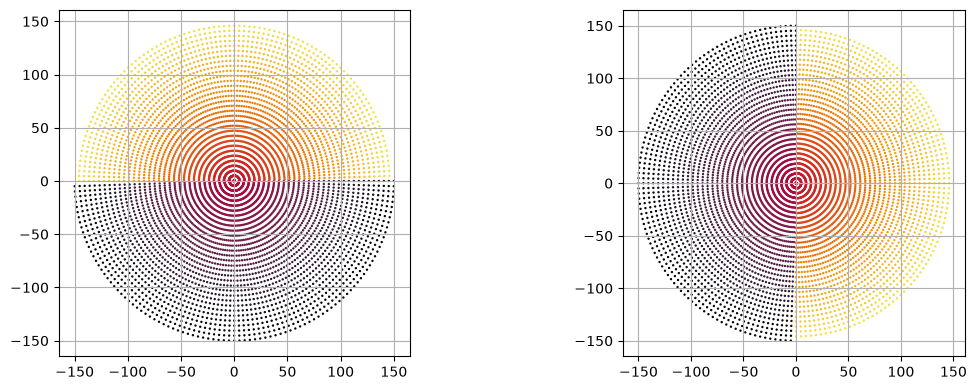

In [21]:
##NOTE: Definitely `sample=slice(0,-1,8)` but why diff colour? <<-- changed color to 'sample'
pre=rpre
rlp.plot.traj2d(f'{pre}.h5', sample=slice(0,-1,8), color='sample')

[16:59:29] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[16:59:29] [Traj  ] Discarded 3512 points (7.15%) outside matrix


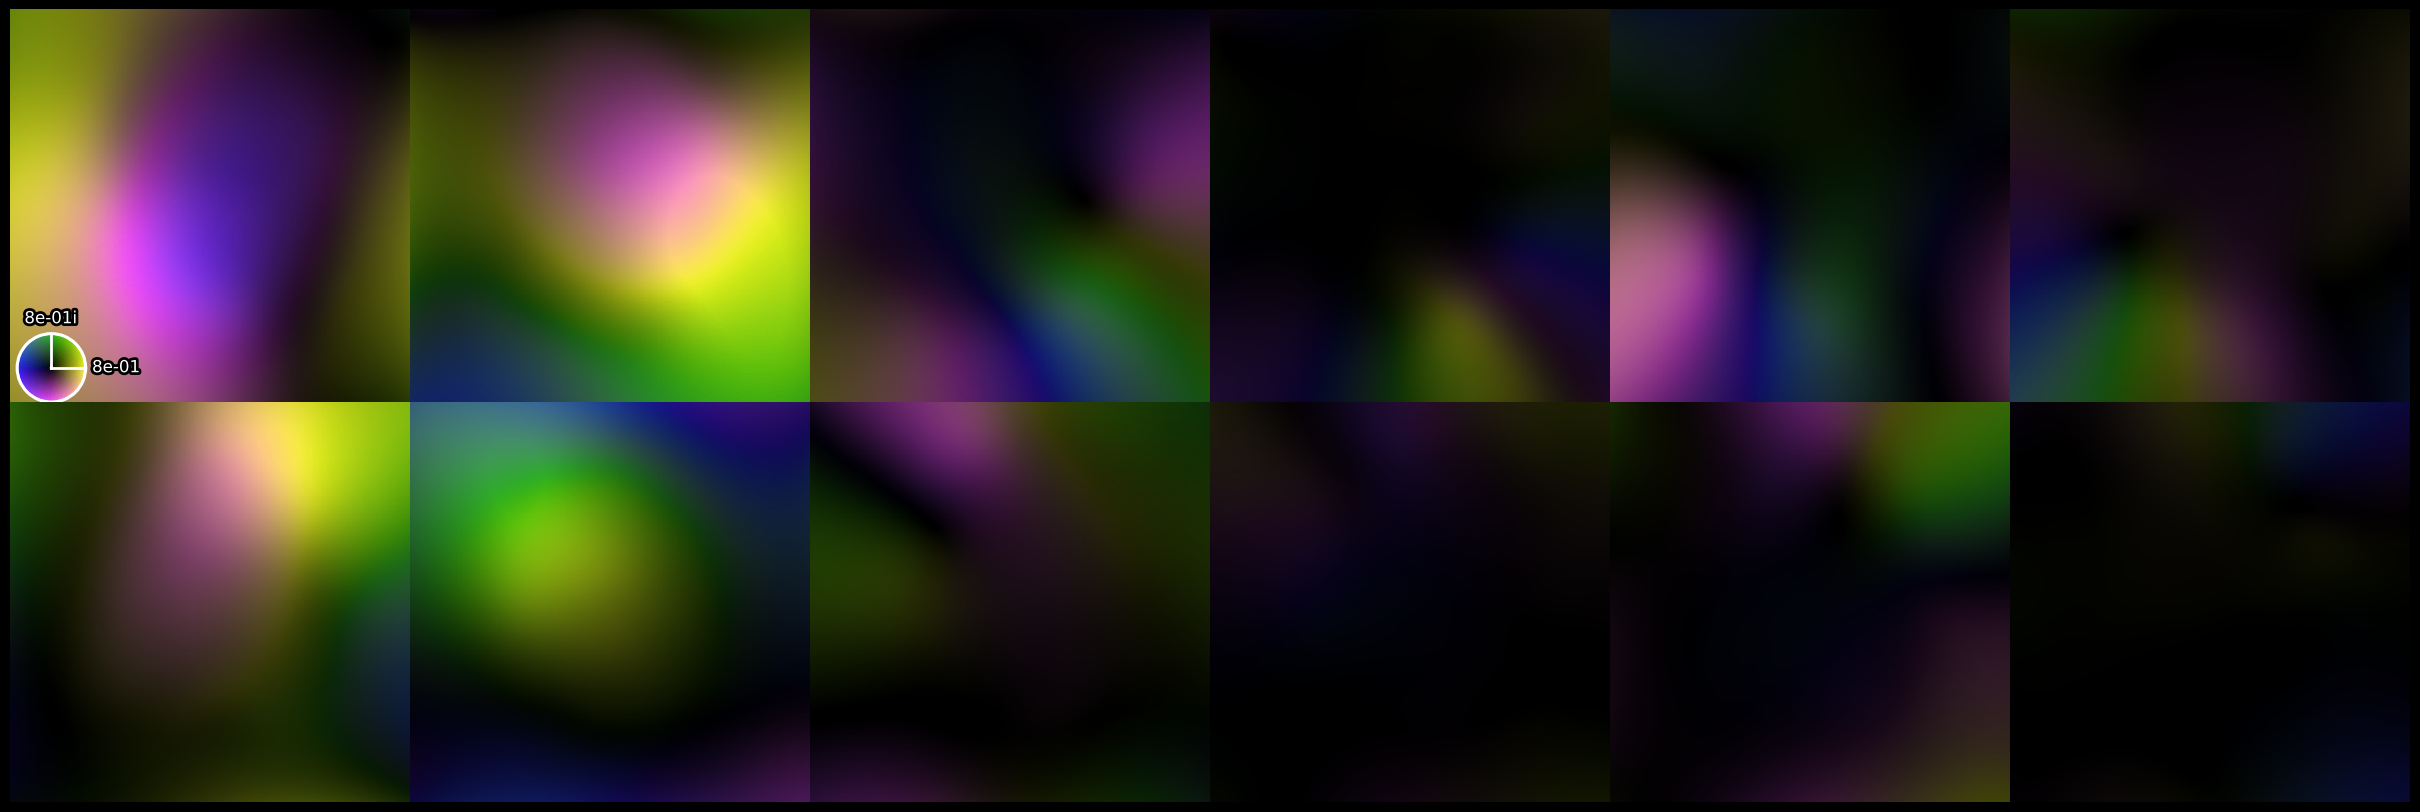

In [22]:
!riesling sense-calib2 {pre}.h5 {pre}-sk.h5
!riesling sense-maps2 {pre}-sk.h5 {pre}.h5 {pre}-sm.h5
display(rlp.plot.sense(f'{pre}-sm.h5',rows=2,rotates=1))

In [23]:
!riesling "recon-lsq2" --precon-p=1 --sense="{rpre}-sk.h5" "{rpre}.h5" "{rpre}-rss.h5"

[16:59:30] [Traj  ] Discarded 3512 points (7.15%) outside matrix


[16:59:31] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[16:59:31] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[16:59:31] [Traj  ] Discarded 3512 points (7.15%) outside matrix


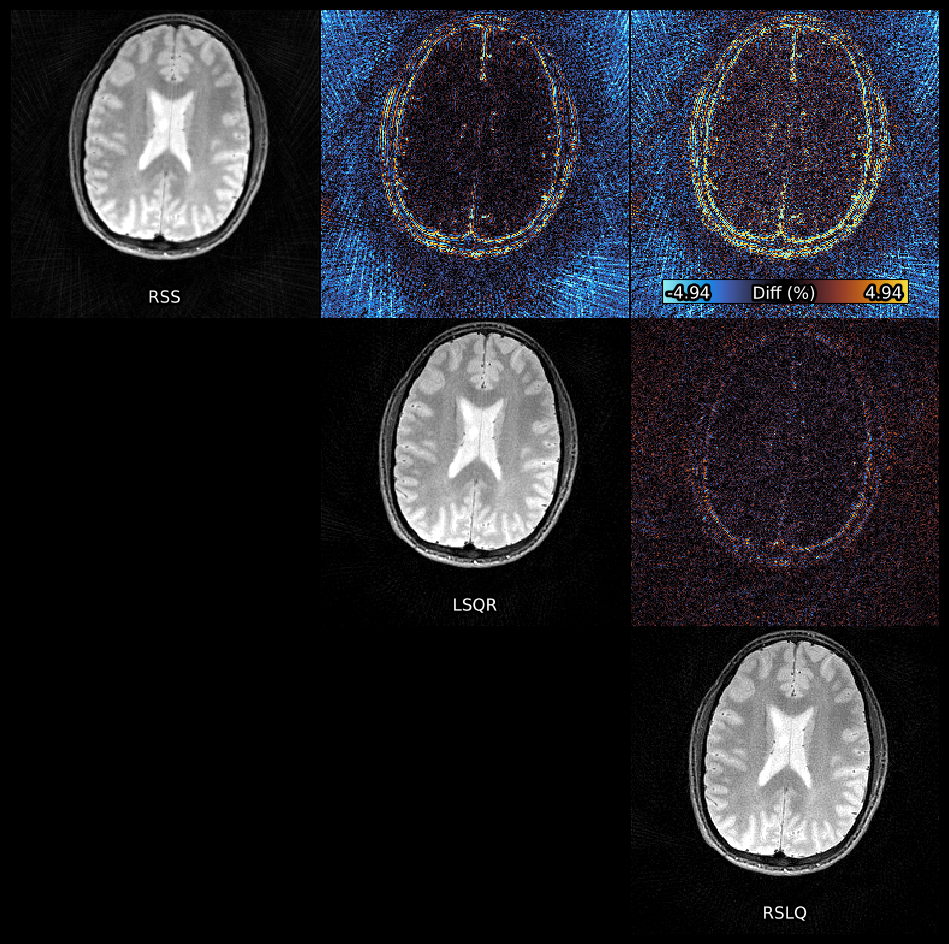

In [24]:
algos={'rss':'recon-rss2', 'lsqr':'recon-lsq2', 'rslq':'recon-rlsq2'}
recons=['rss', 'lsqr', 'rslq']
titles=['RSS', 'LSQR', 'RSLQ']
opts = {'rss':f' ', 
        'lsqr':f'--precon-p=1 --sense="{rpre}-sk.h5"',
        'rslq':f'--precon-p=1 --sense="{rpre}-sk.h5" --l1=1e-3'}
for t in recons:
    algo = algos[t]
    opt = opts[t]
    !riesling {algo} {opt} "{rpre}.h5" "{rpre}-{t}.h5"
files=[f'{rpre}-{t}.h5' for t in recons]
rlp.plot.diff_matrix(files, titles=titles, rotates=1)

In [25]:
!riesling recon-rss2 "{rpre}.h5" "{rpre}-rss.h5"
!riesling recon-lsq2 --precon-p=1 --sense="{rpre}-sk.h5" "{rpre}.h5" "{rpre}-lsq.h5"
!riesling recon-rlsq2 --precon-p=1 --sense="{rpre}-sk.h5" --l1=1e-3 "{rpre}.h5" "{rpre}-rlsq.h5"

[16:59:36] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[16:59:36] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[16:59:36] [Traj  ] Discarded 3512 points (7.15%) outside matrix


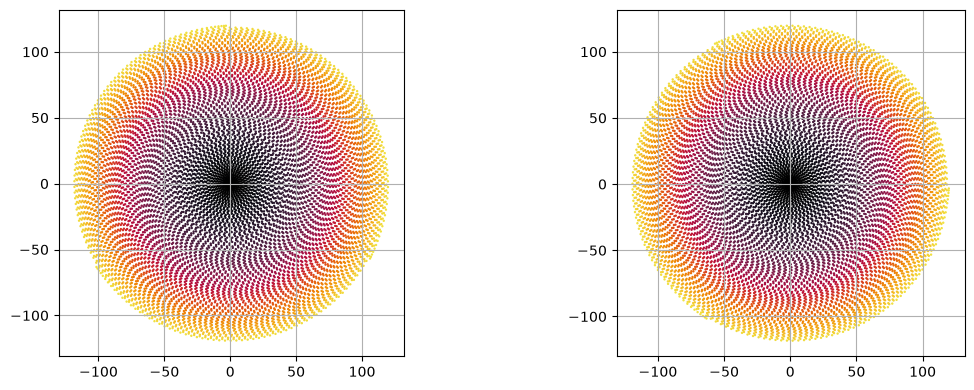

In [26]:
rlp.plot.traj2d(f'{spre}.h5', sample=slice(0,-1,8), color='sample')

[16:59:40] [Traj  ] Discarded 4132 points (5.08%) outside matrix
[16:59:41] [Traj  ] Discarded 4132 points (5.08%) outside matrix


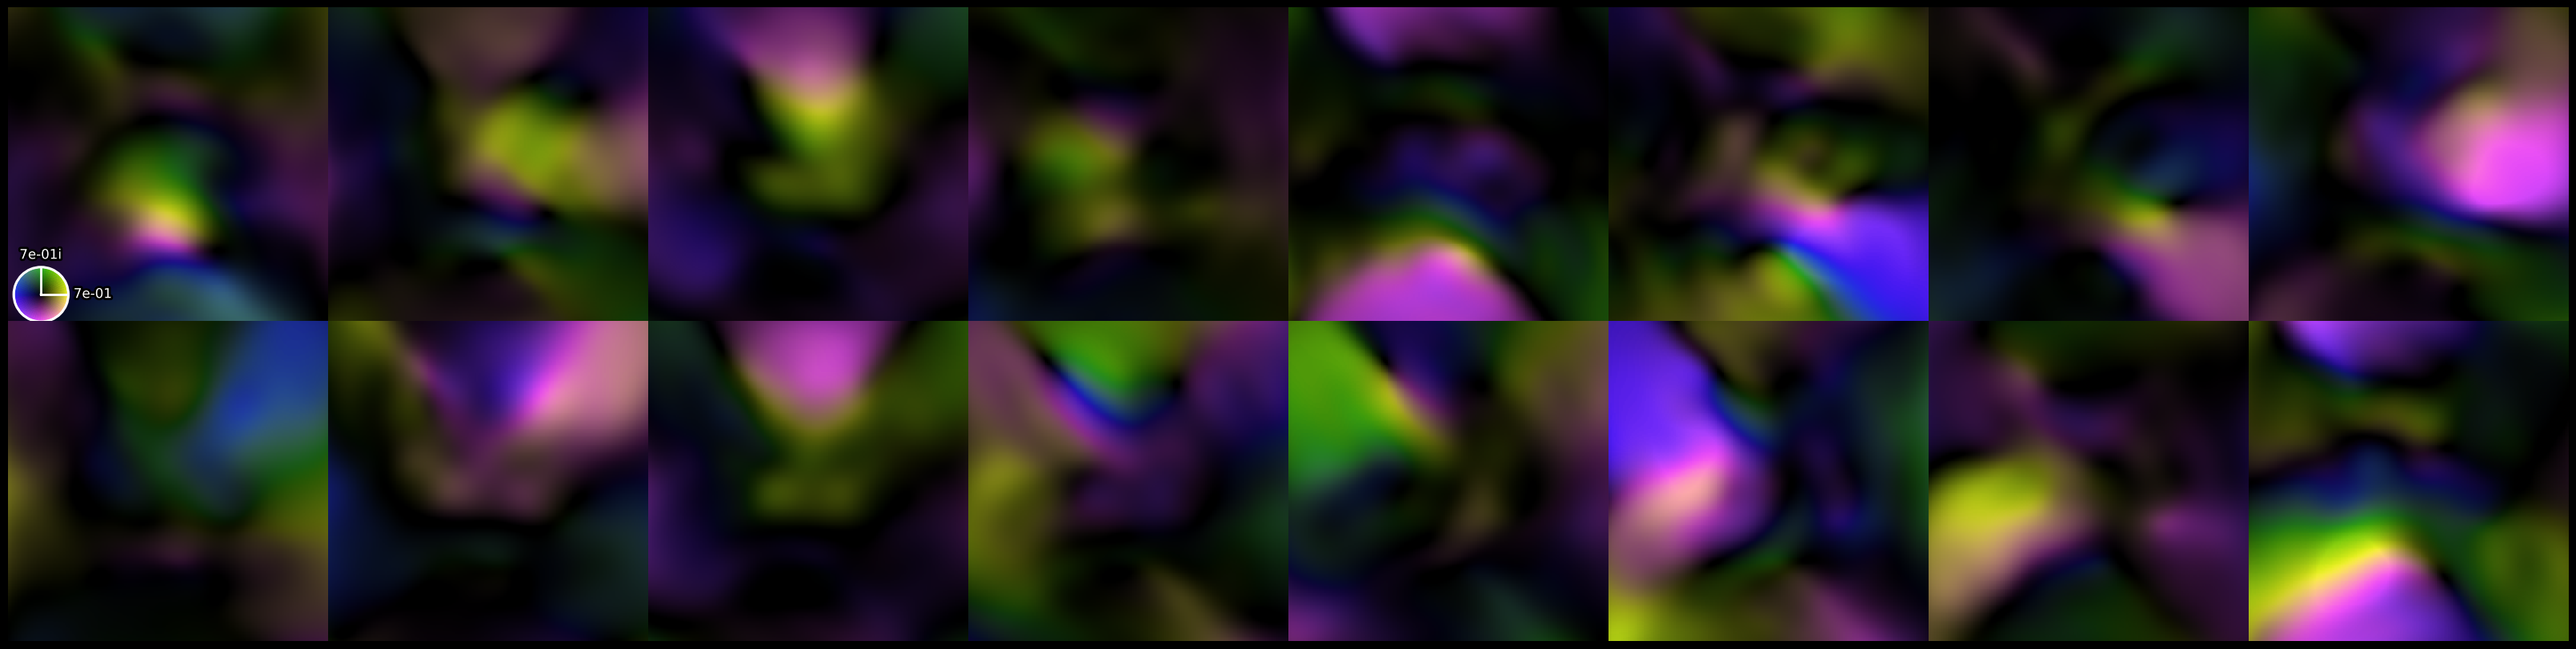

In [27]:
!riesling sense-calib2 "{spre}.h5" "{spre}-sk.h5"
!riesling sense-maps2 "{spre}-sk.h5" "{spre}.h5" "{spre}-sm.h5"
display(rlp.plot.sense(f'{spre}-sm.h5',rows=2,rotates=1))

[16:59:42] [recon-rss2] Welcome to RIESLING
[16:59:42] [HD5   ] Opened rrsg/rrsg-spiral.h5 for reading id 72057594037927936
[16:59:42] [Traj  ] Discarded 4132 points (5.08%) outside matrix
[16:59:42] [Traj  ] 2D Samples 27121 Traces 3 Matrix [220, 220] FOV [220.00, 220.00]
[16:59:42] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[16:59:42] [Kernel] Width 4 Scale 1.5302638e-06
[16:59:42] [Traj  ] Nominal FOV, matrix [220, 220]
[16:59:42] [Traj  ] Nominal matrix [220, 220] grid matrix [286, 286] over-sampling [1.30, 1.30]
[16:59:42] [Traj  ] Ignored 4275 invalid trajectory points, 77088 remain
[16:59:42] [Traj  ] Nominal FOV, matrix [220, 220]
[16:59:42] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[16:59:42] [Kernel] Width 4 Scale 1.5302638e-06
[16:59:42] [Apodiz] Shape [220, 220] Grid shape [286, 286] Scale 220
[16:59:42] [NUFFT ] ishape [220, 220, 1, 16] oshape [16, 27121, 3] grid [286, 286, 1, 16]
[16:59:42] [Precon] λ 0.000 pow 1.000
[16:59:42] [Precon] Starting precond

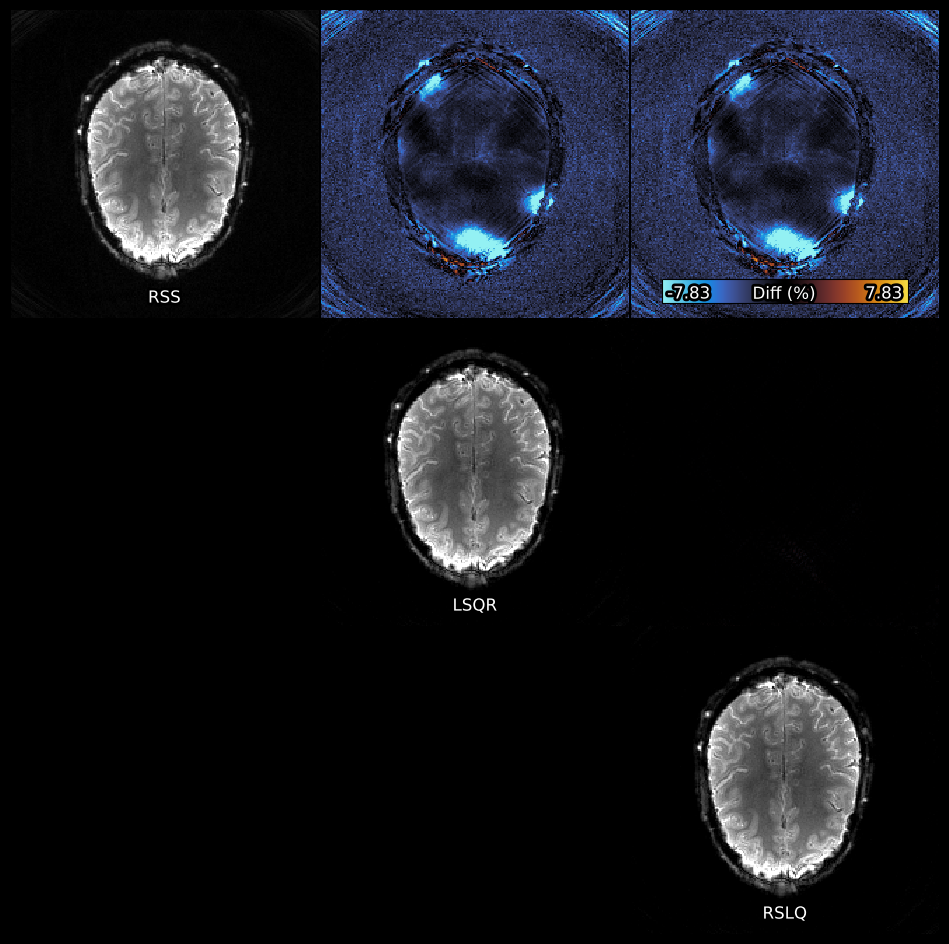

In [28]:
algos={'rss':'recon-rss2', 'lsq':'recon-lsq2', 'rlsq':'recon-rlsq2'}
recons=['rss', 'lsq', 'rlsq']
titles=['RSS', 'LSQR', 'RSLQ']
opts = {'rss':f' ', 
        'lsq':f'--precon-p=1 --sense="{spre}-sk.h5"',
        'rlsq':f'--precon-p=1 --sense="{spre}-sk.h5" --l1=1e-3'}
for t in recons:
    algo = algos[t]
    opt = opts[t]
    #print(f"{spre}-{t}")
    !riesling {algo} {opt} "{spre}.h5" "{spre}-{t}.h5" -v2
    #print(f"saved {spre}-{t}")
files=[f'{spre}-{t}.h5' for t in recons]
rlp.plot.diff_matrix(files, titles=titles, rotates=1)

- check fov `Could not read FOV from 'ov=256,256,2`
- check `sense-res` <<-- what did this change to>
- check `Error reading attribute matrix from trajectory.`

[16:59:44] [Traj  ] Discarded 3512 points (7.15%) outside matrix


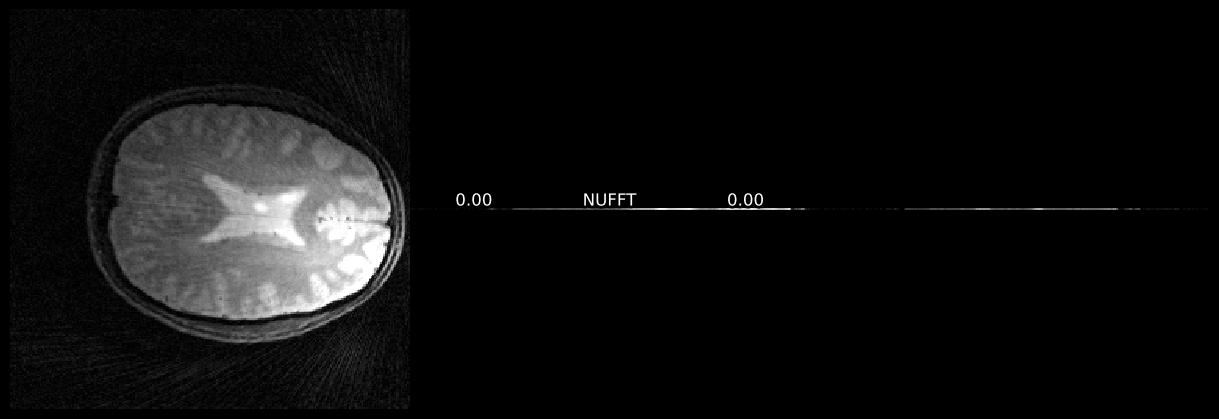

In [29]:
!riesling op-nufft2 {rpre}.h5 {rpre}-nufft.h5
rlp.plot.planes(f'{rpre}-nufft.h5', title='NUFFT')

In [ ]:
x = rlp.io.read_data(f"{rpre}-nufft.h5")
rl

(1, 12, 1, 1, 256, 256)